# Debug 06: Python hash seed trajectories

Compare two ordinary SMAC jobs with two jobs launched under the same fixed `PYTHONHASHSEED`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt

candidate = Path("experiments/hartmann/Debug_06")
BASE_DIR = candidate if candidate.exists() else Path.cwd()

RUN_GROUPS = {
    "Basic SMAC jobs": BASE_DIR / "basic_smac_two_jobs",
    "Fixed PYTHONHASHSEED jobs": BASE_DIR / "fixed_pythonhashseed_two_jobs",
}

plt.style.use("seaborn-v0_8-colorblind")
BASE_DIR

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 668,

PosixPath('/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/hartmann/Debug_06')

In [2]:
def load_costs(run_dir: Path) -> list[float]:
    runhistory_path = run_dir / "runhistory.json"
    if not runhistory_path.exists():
        raise FileNotFoundError(f"Missing runhistory: {runhistory_path}")

    with open(runhistory_path) as fh:
        runhistory = json.load(fh)

    trials = sorted(
        runhistory["data"],
        key=lambda item: (item.get("starttime") or 0.0, item.get("endtime") or 0.0),
    )
    return [float(trial["cost"]) for trial in trials]


def best_so_far(costs: list[float]) -> list[float]:
    best = []
    current = float("inf")
    for cost in costs:
        current = min(current, cost)
        best.append(current)
    return best


def discover_runs(group_dir: Path) -> dict[str, Path]:
    runs = {}
    for runhistory_path in sorted(group_dir.glob("*/0/runhistory.json")):
        runs[runhistory_path.parents[1].name] = runhistory_path.parent
    if not runs:
        raise FileNotFoundError(f"No completed SMAC runs found below {group_dir}")
    return runs


def load_group(group_dir: Path) -> dict[str, dict[str, list[float]]]:
    group = {}
    for run_label, run_dir in discover_runs(group_dir).items():
        costs = load_costs(run_dir)
        group[run_label] = {
            "raw": costs,
            "best": best_so_far(costs),
        }
    return group

In [3]:
groups = {name: load_group(path) for name, path in RUN_GROUPS.items()}

for group_name, runs in groups.items():
    print(group_name)
    for run_label, trajectories in runs.items():
        print(
            f"  {run_label}: "
            f"{len(trajectories['raw'])} trials, "
            f"final best={trajectories['best'][-1]:.6f}"
        )

Basic SMAC jobs
  basic_run_a: 400 trials, final best=-3.198241
  basic_run_b: 400 trials, final best=-3.193759
Fixed PYTHONHASHSEED jobs
  fixed_hashseed_run_a: 400 trials, final best=-3.202249
  fixed_hashseed_run_b: 400 trials, final best=-3.202249


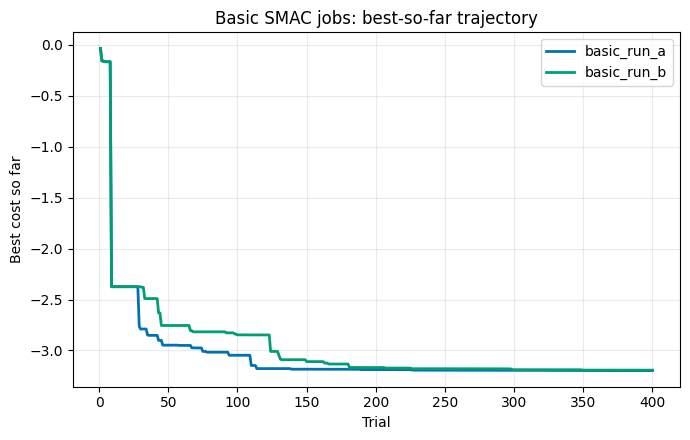

In [4]:
def plot_group(group_name: str) -> None:
    runs = groups[group_name]
    fig, ax = plt.subplots(figsize=(7, 4.5))

    for run_label, trajectories in runs.items():
        x = range(1, len(trajectories["best"]) + 1)
        ax.plot(x, trajectories["best"], label=run_label, linewidth=2)

    ax.set_title(f"{group_name}: best-so-far trajectory")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Best cost so far")
    ax.grid(alpha=0.25)
    ax.legend()

    fig.tight_layout()
    plt.show()


plot_group("Basic SMAC jobs")

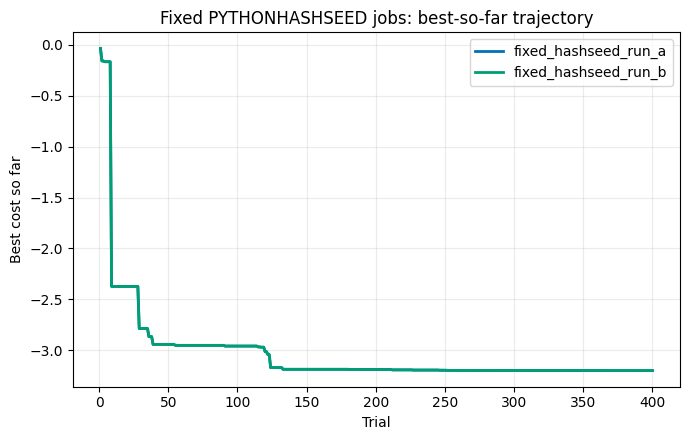

In [5]:
plot_group("Fixed PYTHONHASHSEED jobs")